# 05 — Full Experiment Suite

Trains **all 13 experiments** in-process with live progress bars, then produces a results table and comparison plots.

| Group | Experiments | Supervision |
|-------|-------------|-------------|
| Sequence (self-supervised LM) | Transformer / LSTM / GRU × rank_only / strength_only / hybrid | Unsupervised |
| Vector classifier (supervised upper bound) | MLP / DeepSets × raw markers | Supervised |
| Vector autoencoder (unsupervised baseline) | MLP autoencoder / DeepSets autoencoder × raw markers | Unsupervised |

**Fair comparison:** Sequence models and vector autoencoders are both unsupervised.  
Compare them on ARI/NMI/kNN purity.  The supervised classifiers are a separate upper bound.

## 0. Settings

In [1]:
# ── User-editable ───────────────────────────────────────────────────────────
MAX_EPOCHS     = 30    # epochs per experiment (set higher for a full run)
PATIENCE       = 5     # early-stopping patience
SEQ_BATCH_SIZE = 128   # batch size for sequence models
VEC_BATCH_SIZE = 256   # batch size for vector / autoencoder models

# Set to a list of config stems to run a subset,
# e.g. ['transformer_hybrid', 'mlp_raw', 'mlp_autoencoder_raw']
# None = run all 13.
RUN_ONLY = None


## 1. Imports & Paths

In [2]:
import sys, json, datetime, subprocess, warnings
from functools import partial
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm as tqdm_nb
from sklearn.preprocessing import LabelEncoder

from src.data.loader        import load_processed
from src.data.splits        import load_manifest, apply_splits, make_splits
from src.data.tokenization  import tokenize_dataframe
from src.data.vocab         import Vocabulary
from src.models             import build_model, build_vector_model
from src.training.trainer   import Trainer, CellSequenceDataset, CellVectorDataset, CellUnlabeledDataset
from src.utils.config       import load_config
from src.utils.reproducibility import set_seed, resolve_device

set_seed(42)
device = resolve_device('mps')
print(f'Device: {device}')


Device: mps


## 2. Prepare Data (first run only)

In [3]:
DATA_DIR       = PROJECT_ROOT / 'data'
processed_path = DATA_DIR / 'levine32_processed.h5ad'
manifest_path  = DATA_DIR / 'split_manifest.json'

def _run(script):
    r = subprocess.run(
        [sys.executable, str(PROJECT_ROOT / 'scripts' / script)],
        cwd=PROJECT_ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
    )
    for line in r.stdout.splitlines(): print(line)
    if r.returncode != 0:
        raise RuntimeError(f'{script} failed')

if not processed_path.exists():
    print('Running prepare_data.py …')
    _run('prepare_data.py')
else:
    print(f'Found: {processed_path}')

if not manifest_path.exists():
    print('Running make_splits.py …')
    _run('make_splits.py')
else:
    print(f'Found: {manifest_path}')


Found: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/data/levine32_processed.h5ad
Found: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/data/split_manifest.json


## 3. Load Dataset & Splits

In [4]:
base_cfg = load_config(str(PROJECT_ROOT / 'configs' / 'base.yaml'))
PREP_CFG = base_cfg['preprocessing']

print('Loading processed data …')
df = load_processed(processed_path)
print(f'  {len(df):,} cells × {len(df.columns)} columns')

splits    = load_manifest(manifest_path)
split_dfs = apply_splits(df, splits)
for name, sdf in split_dfs.items():
    print(f'  {name:<25} {len(sdf):>7,} cells')


Loading processed data …
  265,627 cells × 98 columns
  labeled_train              62,510 cells
  labeled_val                20,837 cells
  labeled_test               20,837 cells
  unlabeled_train           145,298 cells
  unlabeled_val              16,145 cells
  train                     207,808 cells
  val_self_supervised        16,145 cells
  val_downstream             20,837 cells
  test                       20,837 cells


## 4. Tokenise (sequence models — all 3 schemes)

In [5]:
SCHEMES = ['rank_only', 'strength_only', 'hybrid']
tokenized = {}   # scheme → {train: ids, val: ids}
vocabs    = {}   # scheme → Vocabulary

for scheme in tqdm_nb(SCHEMES, desc='Tokenising schemes'):
    train_seqs = tokenize_dataframe(split_dfs['train'],               scheme=scheme, bins=PREP_CFG['bins'])
    val_seqs   = tokenize_dataframe(split_dfs['val_self_supervised'],  scheme=scheme, bins=PREP_CFG['bins'])

    vocab = Vocabulary()
    vocab.build(train_seqs)

    tokenized[scheme] = {
        'train': [vocab.encode(s) for s in train_seqs],
        'val':   [vocab.encode(s) for s in val_seqs],
    }
    vocabs[scheme] = vocab
    print(f'  {scheme:<20}  vocab={len(vocab):,}  train={len(train_seqs):,}  val={len(val_seqs):,}')


Tokenising schemes:   0%|          | 0/3 [00:00<?, ?it/s]

  rank_only             vocab=36  train=207,808  val=16,145
  strength_only         vocab=100  train=207,808  val=16,145
  hybrid                vocab=1,123  train=207,808  val=16,145


## 5. Prepare Vector Data (MLP / DeepSets)

In [6]:
exclude = {'cell_id', 'label'}
marker_cols = [c for c in df.columns
               if c not in exclude and not c.endswith('_rank') and not c.endswith('_bin')]

# Supervised classifier data (labeled_train → val_downstream)
train_vec_df = split_dfs['labeled_train']
val_vec_df   = split_dfs['val_downstream']

le = LabelEncoder()
train_vec_labels = le.fit_transform(train_vec_df['label'].values)
val_vec_labels   = le.transform(val_vec_df['label'].values)
n_markers = len(marker_cols)
n_classes = len(le.classes_)

train_vec_ds = CellVectorDataset(train_vec_df[marker_cols].values.astype('float32'), train_vec_labels)
val_vec_ds   = CellVectorDataset(val_vec_df[marker_cols].values.astype('float32'),   val_vec_labels)
label_map    = {int(i): str(c) for i, c in enumerate(le.classes_)}

# Unsupervised autoencoder data (all train cells → val_self_supervised, no labels)
train_recon_df = split_dfs['train']           # labeled_train + unlabeled_train
val_recon_df   = split_dfs['val_self_supervised']

train_recon_ds = CellUnlabeledDataset(train_recon_df[marker_cols].values.astype('float32'))
val_recon_ds   = CellUnlabeledDataset(val_recon_df[marker_cols].values.astype('float32'))

print(f'n_markers={n_markers}  n_classes={n_classes}')
print(f'train_vec={len(train_vec_labels):,}  val_vec={len(val_vec_labels):,}')
print(f'train_recon={len(train_recon_df):,}  val_recon={len(val_recon_df):,}')
print('Classes:', list(le.classes_))


n_markers=32  n_classes=14
train_vec=62,510  val_vec=20,837
train_recon=207,808  val_recon=16,145
Classes: ['Basophils', 'CD16+_NK_cells', 'CD16-_NK_cells', 'CD34+CD38+CD123+_HSPCs', 'CD34+CD38+CD123-_HSPCs', 'CD34+CD38lo_HSCs', 'CD4_T_cells', 'CD8_T_cells', 'Mature_B_cells', 'Monocytes', 'Plasma_B_cells', 'Pre_B_cells', 'Pro_B_cells', 'pDCs']


## 6. Experiment Definitions

In [7]:
ALL_CONFIGS = [
#    'configs/transformer_rank_only.yaml',
#    'configs/transformer_strength_only.yaml',
#    'configs/transformer_hybrid.yaml',
#    'configs/lstm_rank_only.yaml',
#    'configs/lstm_strength_only.yaml',
#    'configs/lstm_hybrid.yaml',
#    'configs/gru_rank_only.yaml',
#    'configs/gru_strength_only.yaml',
#    'configs/gru_hybrid.yaml',
#    'configs/mlp_raw.yaml',
#    'configs/deepsets_raw.yaml',
    'configs/mlp_autoencoder_raw.yaml',
    'configs/deepsets_autoencoder_raw.yaml',
]

if RUN_ONLY is not None:
    ALL_CONFIGS = [c for c in ALL_CONFIGS if Path(c).stem in RUN_ONLY]

print(f'Running {len(ALL_CONFIGS)} experiments:')
for c in ALL_CONFIGS:
    print(f'  • {Path(c).stem}')


Running 2 experiments:
  • mlp_autoencoder_raw
  • deepsets_autoencoder_raw


## 7. Run All Experiments

In [8]:
import yaml as _yaml

all_results = []

for config_path in tqdm_nb(ALL_CONFIGS, desc='Experiments', unit='exp'):
    name = Path(config_path).stem

    # Load and patch config
    cfg_exp = load_config(
        str(PROJECT_ROOT / 'configs' / 'base.yaml'),
        str(PROJECT_ROOT / config_path),
    )
    cfg_exp['training']['max_epochs'] = MAX_EPOCHS
    cfg_exp['training']['patience']   = PATIENCE

    model_type = cfg_exp['model']['type']
    data_mode  = cfg_exp['model'].get('data_mode', 'sequence')
    scheme     = cfg_exp.get('tokenization', {}).get('scheme', 'raw')

    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    exp_id     = f'{name}_{ts}'
    output_dir = PROJECT_ROOT / 'outputs' / exp_id
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save resolved config so outputs are self-contained
    with open(output_dir / 'config_resolved.yaml', 'w') as _f:
        _yaml.dump(cfg_exp, _f)

    print(f'\n▶  {name}  [{model_type} / {data_mode} / {scheme}]')

    # ── Build dataloaders & model ────────────────────────────────────────────
    if data_mode == 'sequence':
        vocab  = vocabs[scheme]
        ids    = tokenized[scheme]
        pad_id = vocab.pad_id
        max_seq = cfg_exp['model']['max_seq_len']
        collate = partial(CellSequenceDataset.collate_fn, pad_id=pad_id)

        train_loader = DataLoader(
            CellSequenceDataset(ids['train'], pad_id=pad_id, max_seq_len=max_seq),
            batch_size=SEQ_BATCH_SIZE, shuffle=True, collate_fn=collate)
        val_loader = DataLoader(
            CellSequenceDataset(ids['val'],   pad_id=pad_id, max_seq_len=max_seq),
            batch_size=SEQ_BATCH_SIZE, shuffle=False, collate_fn=collate)

        model = build_model(cfg_exp, vocab_size=len(vocab))
        vocab.save(output_dir / 'vocab.json')
        trainer_kw = dict(pad_id=pad_id, mode='sequence')

    elif data_mode == 'vector':
        train_loader = DataLoader(train_vec_ds, batch_size=VEC_BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_vec_ds,   batch_size=VEC_BATCH_SIZE, shuffle=False)
        model = build_vector_model(cfg_exp, n_markers=n_markers, n_classes=n_classes)
        with open(output_dir / 'label_map.json', 'w') as _f:
            json.dump(label_map, _f, indent=2)
        trainer_kw = dict(pad_id=0, mode='vector')

    else:  # reconstruction
        train_loader = DataLoader(train_recon_ds, batch_size=VEC_BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_recon_ds,   batch_size=VEC_BATCH_SIZE, shuffle=False)
        model = build_vector_model(cfg_exp, n_markers=n_markers, n_classes=0)
        trainer_kw = dict(pad_id=0, mode='reconstruction')

    print(f'   {model.__class__.__name__}  params={model.count_parameters():,}')

    # ── Train ────────────────────────────────────────────────────────────────
    tr = cfg_exp['training']
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        output_dir=output_dir,
        lr=tr['lr'],
        weight_decay=tr['weight_decay'],
        max_epochs=tr['max_epochs'],
        patience=tr['patience'],
        grad_clip=tr['grad_clip'],
        mixed_precision=tr.get('mixed_precision', False),
        device=device,
        **trainer_kw,
    )
    result = trainer.train()

    # Metadata for fair-comparison analysis
    input_structure = 'set' if 'deepsets' in model_type else ('sequence' if data_mode == 'sequence' else 'vector')
    supervision_type = 'supervised' if data_mode == 'vector' else 'unsupervised'
    training_objective = {'sequence': 'next_token', 'vector': 'classification', 'reconstruction': 'reconstruction'}[data_mode]

    result.update({
        'name': name, 'model_type': model_type,
        'scheme': scheme, 'data_mode': data_mode,
        'n_params': model.count_parameters(), 'exp_id': exp_id,
        'output_dir': str(output_dir),
        'supervision_type': supervision_type,
        'input_structure': input_structure,
        'training_objective': training_objective,
    })
    all_results.append(result)

    with open(output_dir / 'training_summary.json', 'w') as _f:
        json.dump({k: v for k, v in result.items() if k != 'output_dir'}, _f, indent=2)

    print(f'   ✓ best_val_loss={result["best_val_loss"]:.4f}  epoch={result["best_epoch"]}')

print('\n✅ All experiments complete.')


Experiments:   0%|          | 0/2 [00:00<?, ?exp/s]


▶  mlp_autoencoder_raw  [mlp_autoencoder / reconstruction / rank_only]
   MLPAutoencoder  params=90,944


Epochs:   0%|                                                                                                 …

   ✓ best_val_loss=0.0265  epoch=30

▶  deepsets_autoencoder_raw  [deepsets_autoencoder / reconstruction / rank_only]
   DeepSetsAutoencoder  params=51,840


Epochs:   0%|                                                                                                 …

   ✓ best_val_loss=0.7721  epoch=30

✅ All experiments complete.


## 8. Load All Results from Disk

Merges any results from the current session with every completed experiment found in . Run this cell alone to load previously completed runs without re-training.

In [9]:
import yaml as _yaml

# Start from whatever the training cell produced (may be empty list if skipped)
try:
    _session = {r["exp_id"]: r for r in all_results}
except NameError:
    _session = {}

# Scan outputs/ for every directory that has both required files
_outputs_root = PROJECT_ROOT / "outputs"
_found = 0

for _exp_dir in sorted(_outputs_root.iterdir()):
    if not _exp_dir.is_dir():
        continue
    _summary_p = _exp_dir / "training_summary.json"
    _config_p  = _exp_dir / "config_resolved.yaml"
    if not (_summary_p.exists() and _config_p.exists()):
        continue

    _exp_id = _exp_dir.name

    # Already loaded from this session — skip
    if _exp_id in _session:
        continue

    try:
        with open(_summary_p) as _f:
            _s = json.load(_f)
        with open(_config_p) as _f:
            _cfg = _yaml.safe_load(_f)
    except Exception as _e:
        print(f"  ⚠ Could not load {_exp_id}: {_e}")
        continue

    _model_type = _cfg.get("model", {}).get("type", "?")
    _data_mode  = _cfg.get("model", {}).get("data_mode", "sequence")
    _scheme     = _cfg.get("tokenization", {}).get("scheme", "raw")

    # Derive metadata (backwards compat: older runs may not have these in JSON)
    _supervision  = _s.get("supervision_type",
                           "supervised" if _data_mode == "vector" else "unsupervised")
    _input_struct = _s.get("input_structure",
                           "set" if "deepsets" in _model_type else
                           ("sequence" if _data_mode == "sequence" else "vector"))
    _objective    = _s.get("training_objective",
                           {"sequence": "next_token", "vector": "classification",
                            "reconstruction": "reconstruction"}.get(_data_mode, "?"))

    _row = {
        "name":               _exp_dir.name.rsplit("_", 2)[0],   # strip timestamp
        "exp_id":             _exp_id,
        "model_type":         _model_type,
        "data_mode":          _data_mode,
        "scheme":             _scheme,
        "supervision_type":   _supervision,
        "input_structure":    _input_struct,
        "training_objective": _objective,
        "best_val_loss":      _s.get("best_val_loss",  float("nan")),
        "best_epoch":         _s.get("best_epoch",     -1),
        "total_epochs":       _s.get("total_epochs",   -1),
        "n_params":           _s.get("n_params",        0),
        "output_dir":         str(_exp_dir),
    }
    _session[_exp_id] = _row
    _found += 1

all_results_combined = list(_session.values())
results_df = pd.DataFrame(all_results_combined)

print(f"Session runs    : {len(all_results_combined) - _found}")
print(f"Loaded from disk: {_found}")
print(f"Total           : {len(all_results_combined)}")
if not results_df.empty:
    print()
    _show = ["name", "model_type", "scheme", "supervision_type", "training_objective",
             "best_val_loss", "best_epoch"]
    print(results_df[[c for c in _show if c in results_df.columns]]
          .sort_values(["supervision_type", "best_val_loss"]).to_string(index=False))


Session runs    : 2
Loaded from disk: 4
Total           : 6

                    name           model_type    scheme supervision_type training_objective  best_val_loss  best_epoch
                 mlp_raw                  mlp rank_only       supervised     classification       0.006474          29
            deepsets_raw             deepsets rank_only       supervised     classification       1.407970          30
     mlp_autoencoder_raw      mlp_autoencoder rank_only     unsupervised     reconstruction       0.026519          30
deepsets_autoencoder_raw deepsets_autoencoder rank_only     unsupervised     reconstruction       0.772096          30
      transformer_hybrid          transformer    hybrid     unsupervised         next_token       1.106588          28
             lstm_hybrid                 lstm    hybrid     unsupervised         next_token       1.344820          30


In [10]:
display_cols = ["name", "model_type", "scheme", "data_mode", "best_val_loss", "best_epoch", "total_epochs", "n_params"]
summary = results_df[[c for c in display_cols if c in results_df.columns]].sort_values("best_val_loss").reset_index(drop=True)
summary["best_val_loss"] = summary["best_val_loss"].round(4)

try:
    from IPython.display import display as ipy_display
    ipy_display(summary.style
        .background_gradient(subset=["best_val_loss"], cmap="RdYlGn_r")
        .format({"best_val_loss": "{:.4f}", "n_params": "{:,}"})
        .set_caption("All experiments — sorted by best validation loss"))
except Exception:
    print(summary.to_string(index=False))


,name,model_type,scheme,data_mode,best_val_loss,best_epoch,total_epochs,n_params
0,mlp_raw,mlp,rank_only,vector,0.0065,29,30,"59,662"
1,mlp_autoencoder_raw,mlp_autoencoder,rank_only,reconstruction,0.0265,30,30,"90,944"
2,deepsets_autoencoder_raw,deepsets_autoencoder,rank_only,reconstruction,0.7721,30,30,"51,840"
3,transformer_hybrid,transformer,hybrid,sequence,1.1066,28,30,"738,816"
4,lstm_hybrid,lstm,hybrid,sequence,1.3448,30,30,"540,288"
5,deepsets_raw,deepsets,rank_only,vector,1.4080,30,30,"14,414"


## 9. Results Summary

## 9. Training Curves

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_66734/804526350.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


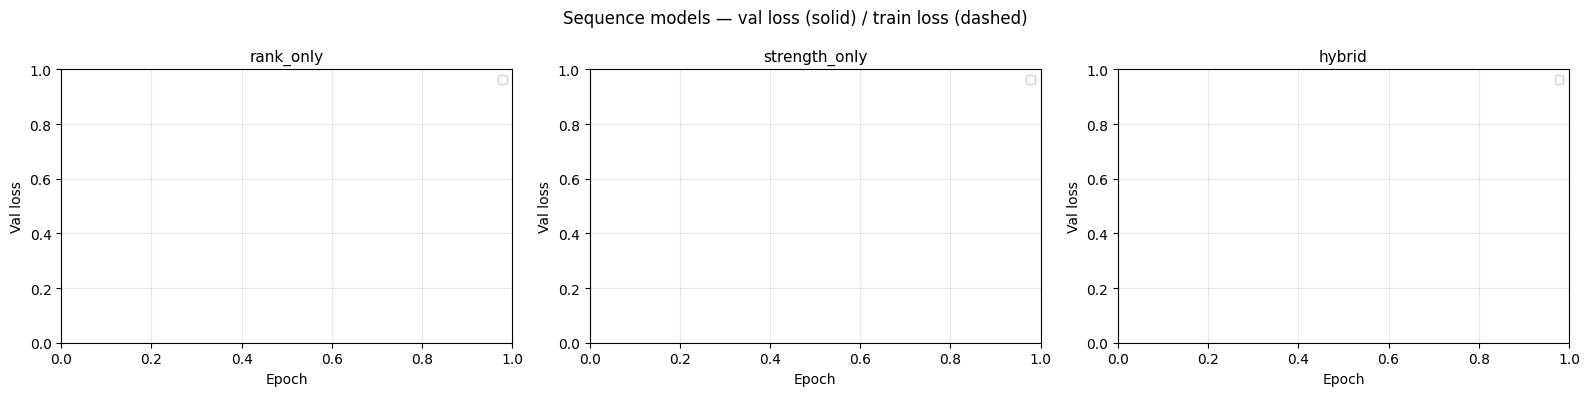

In [11]:
COLORS = {'transformer': '#2196F3', 'lstm': '#FF9800', 'gru': '#4CAF50',
           'mlp': '#9C27B0', 'deepsets': '#F44336'}

# ── Sequence models: one subplot per scheme ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, scheme in zip(axes, ['rank_only', 'strength_only', 'hybrid']):
    ax.set_title(scheme, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val loss')
    for r in all_results:
        if r['data_mode'] != 'sequence' or r['scheme'] != scheme:
            continue
        csv_p = Path(r['output_dir']) / 'training_log.csv'
        if not csv_p.exists():
            continue
        log = pd.read_csv(csv_p)
        c = COLORS.get(r['model_type'], 'grey')
        ax.plot(log['epoch'], log['val_loss'],   color=c, linewidth=2,   label=r['model_type'], alpha=0.9)
        ax.plot(log['epoch'], log['train_loss'], color=c, linewidth=0.9, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Sequence models — val loss (solid) / train loss (dashed)', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'nb05_sequence_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Vector models ─────────────────────────────────────────────────────────────
vec_results = [r for r in all_results if r['data_mode'] == 'vector']
if vec_results:
    fig, ax = plt.subplots(figsize=(7, 4))
    for r in vec_results:
        csv_p = Path(r['output_dir']) / 'training_log.csv'
        if not csv_p.exists():
            continue
        log = pd.read_csv(csv_p)
        c = COLORS.get(r['model_type'], 'grey')
        ax.plot(log['epoch'], log['val_loss'],   color=c, linewidth=2,   label=f"{r['model_type']} val",   alpha=0.9)
        ax.plot(log['epoch'], log['train_loss'], color=c, linewidth=0.9, linestyle='--', label=f"{r['model_type']} train", alpha=0.4)
    ax.set_title('Vector models — cross-entropy loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'outputs' / 'nb05_vector_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


## 10. Best Validation Loss — Bar Chart

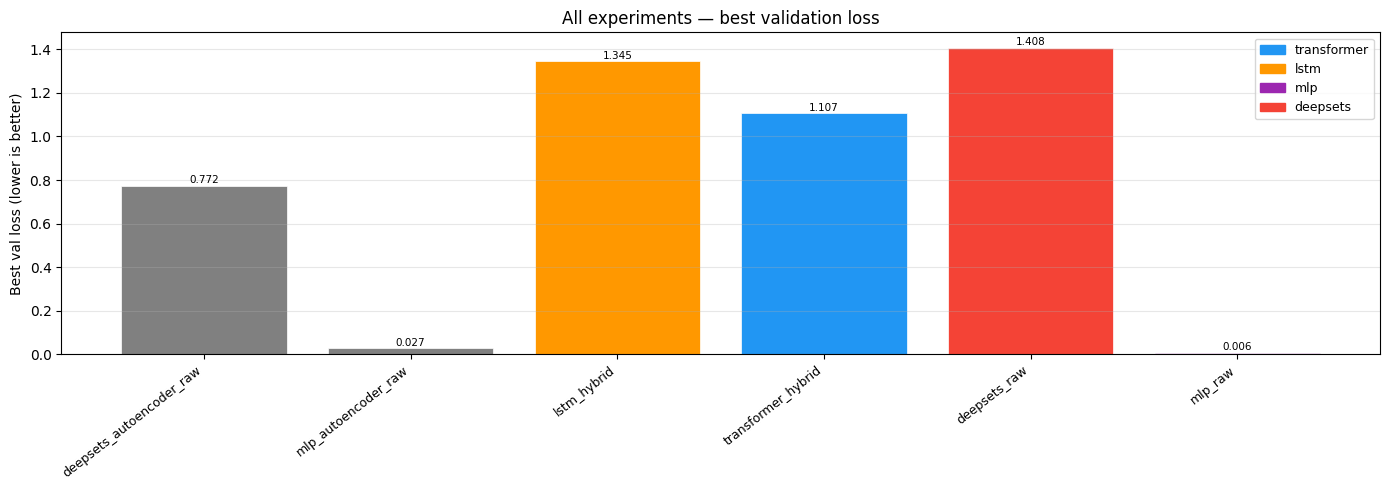

In [12]:
ok = results_df.sort_values(['data_mode', 'model_type', 'scheme']).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [COLORS.get(r, 'grey') for r in ok['model_type']]
bars = ax.bar(range(len(ok)), ok['best_val_loss'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(ok)))
ax.set_xticklabels(ok['name'], rotation=38, ha='right', fontsize=9)
ax.set_ylabel('Best val loss (lower is better)')
ax.set_title('All experiments — best validation loss')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, ok['best_val_loss']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=m) for m, c in COLORS.items() if m in ok['model_type'].values]
ax.legend(handles=handles, fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'nb05_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. UMAP Embeddings (colored by cell type)

Loads each model checkpoint, extracts embeddings on `val_downstream` (labeled cells), then renders a UMAP per experiment.

In [13]:
import warnings
import yaml as _yaml
from src.evaluation.metrics import extract_embeddings, extract_embeddings_vector, compute_umap

# ── Tokenise val_downstream for each scheme (shared across sequence models) ─────
_vd_seqs_cache = {}
_vd_ids_cache  = {}
for _sch in tqdm_nb(['rank_only', 'strength_only', 'hybrid'], desc='Tokenising val_downstream', leave=False):
    _seqs = tokenize_dataframe(split_dfs['val_downstream'], scheme=_sch, bins=PREP_CFG['bins'])
    _vd_ids_cache[_sch] = [vocabs[_sch].encode(s) for s in _seqs]

_vd_labels = split_dfs['val_downstream']['label'].values   # ground-truth cell types

# ── Extract embeddings + compute UMAP for every result with a checkpoint ────────
_umaps = {}   # exp_id → {coords, labels, name}

for _, _row in tqdm_nb(results_df.iterrows(), total=len(results_df), desc='Computing UMAPs', unit='exp'):
    _ckpt_p = Path(_row['output_dir']) / 'best_checkpoint.pt'
    _cfg_p  = Path(_row['output_dir']) / 'config_resolved.yaml'
    if not _ckpt_p.exists() or not _cfg_p.exists():
        print(f"  skip {_row['name']} — checkpoint missing")
        continue

    try:
        _ckpt = torch.load(_ckpt_p, map_location='cpu', weights_only=False)
        with open(_cfg_p) as _f:
            _cfg_e = _yaml.safe_load(_f)

        if _row['data_mode'] == 'sequence':
            _model = build_model(_cfg_e, vocab_size=_ckpt['vocab_size'])
            _model.load_state_dict(_ckpt['model_state_dict'])
            _model.eval()

            _sch    = _row['scheme']
            _pad_id = vocabs[_sch].pad_id
            _max_s  = _cfg_e['model']['max_seq_len']
            _collate = partial(CellSequenceDataset.collate_fn, pad_id=_pad_id)
            _ds = CellSequenceDataset(_vd_ids_cache[_sch], pad_id=_pad_id, max_seq_len=_max_s)
            _loader = DataLoader(_ds, batch_size=256, collate_fn=_collate)
            _embs   = extract_embeddings(_model, _loader, device='cpu')
            _labels = _vd_labels

        else:
            _model = build_vector_model(_cfg_e,
                                        n_markers=_ckpt['n_markers'],
                                        n_classes=_ckpt['n_classes'])
            _model.load_state_dict(_ckpt['model_state_dict'])
            _model.eval()

            _ds = CellVectorDataset(
                val_vec_df[marker_cols].values.astype('float32'),
                np.zeros(len(val_vec_df), dtype=int),
            )
            _loader = DataLoader(_ds, batch_size=256)
            _embs   = extract_embeddings_vector(_model, _loader, device='cpu')
            _labels = val_vec_df['label'].values

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _coords = compute_umap(_embs, n_neighbors=15, min_dist=0.1, seed=42)

        _umaps[_row['exp_id']] = {
            'coords': _coords,
            'labels': _labels,
            'name':   _row['name'],
        }

    except Exception as _e:
        import traceback
        print(f"  ⚠  {_row['name']}: {_e}")
        traceback.print_exc()

print(f"\nUMAP computed for {len(_umaps)}/{len(results_df)} experiments.")


Tokenising val_downstream:   0%|          | 0/3 [00:00<?, ?it/s]

Computing UMAPs:   0%|          | 0/6 [00:00<?, ?exp/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



UMAP computed for 6/6 experiments.


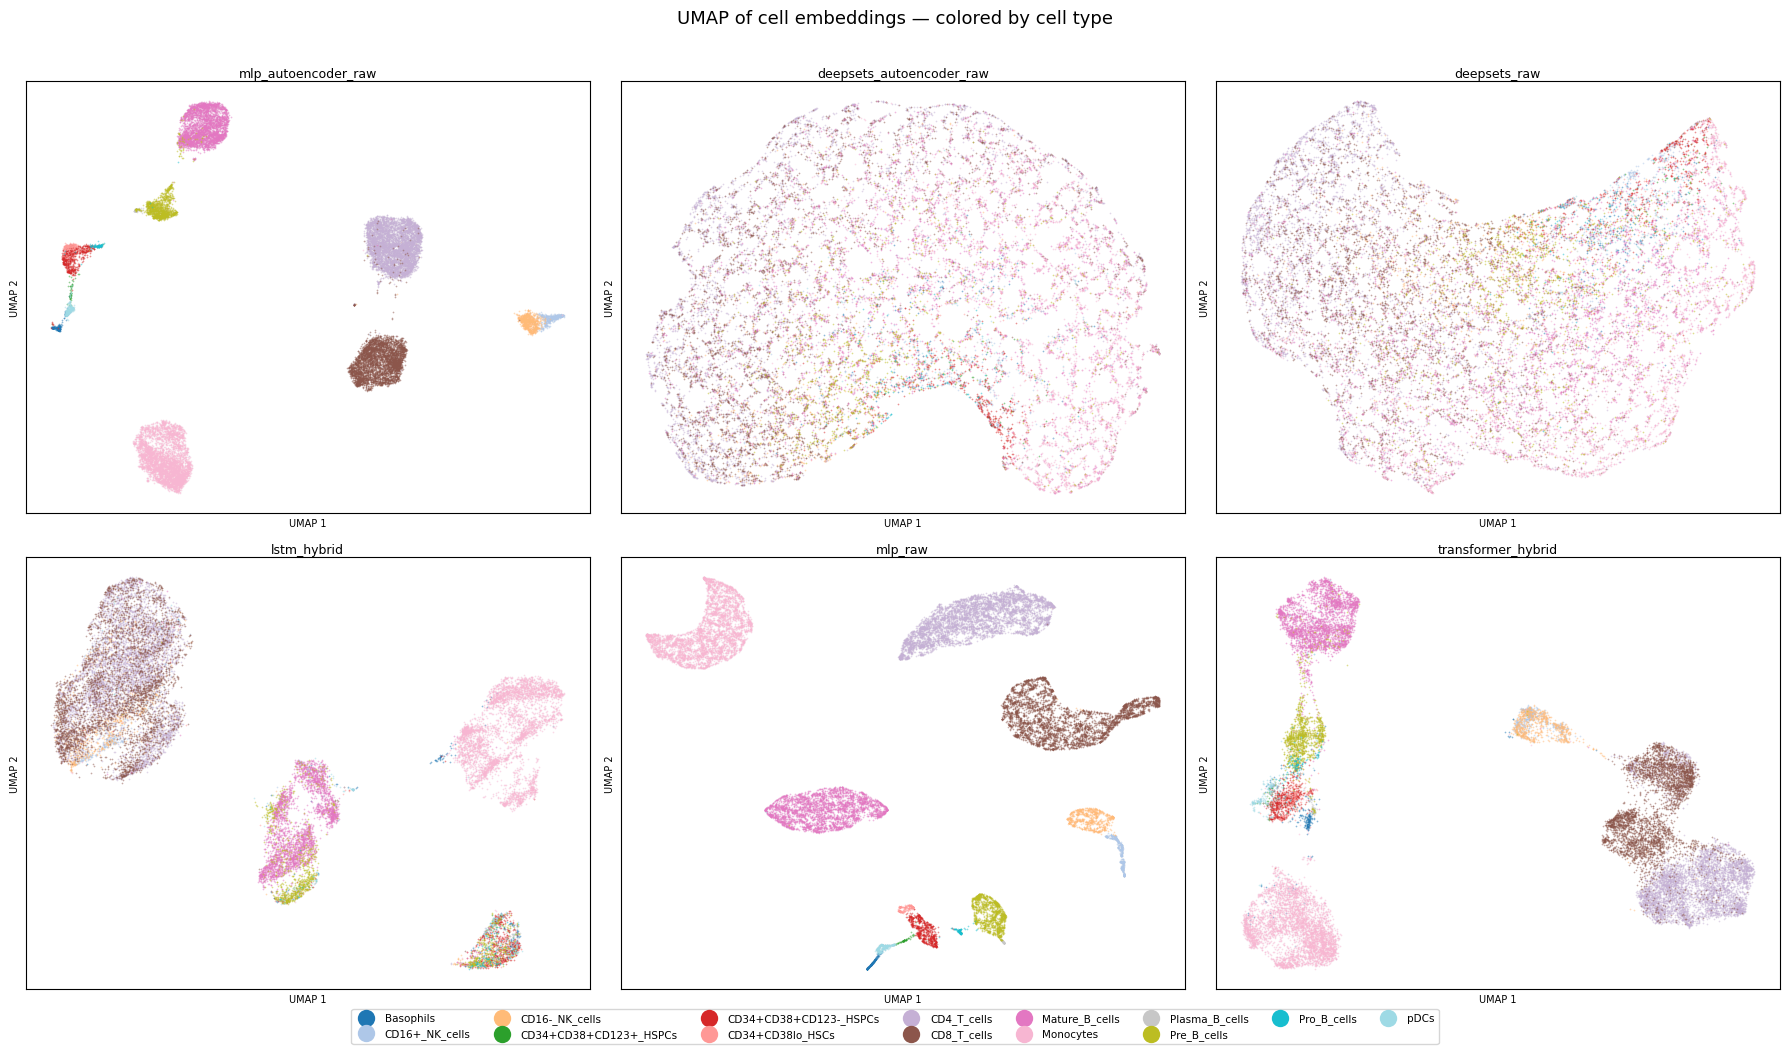

Saved → outputs/nb05_umaps.png  (6 panels)


In [14]:
if not _umaps:
    print("No UMAPs to plot — run the extraction cell first.")
else:
    # ── Shared colour palette for cell types ────────────────────────────────────
    _all_cell_types = sorted({t for v in _umaps.values() for t in v['labels']})
    _cmap = plt.get_cmap('tab20', len(_all_cell_types))
    _type_color = {t: _cmap(i) for i, t in enumerate(_all_cell_types)}

    ncols = 3
    nrows = (len(_umaps) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes_flat = np.array(axes).flatten()

    for ax, (exp_id, data) in zip(axes_flat, _umaps.items()):
        coords = data['coords']
        labels = data['labels']
        for ct in _all_cell_types:
            mask = labels == ct
            if not mask.any():
                continue
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[_type_color[ct]], s=1.5, alpha=0.5,
                       label=ct, rasterized=True, linewidths=0)
        ax.set_title(data['name'], fontsize=9, pad=3)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel('UMAP 1', fontsize=7)
        ax.set_ylabel('UMAP 2', fontsize=7)

    for ax in axes_flat[len(_umaps):]:
        ax.set_visible(False)

    # ── Shared legend ────────────────────────────────────────────────────────────
    _handles = [
        plt.scatter([], [], c=[_type_color[t]], s=25, label=t, linewidths=0)
        for t in _all_cell_types
    ]
    fig.legend(handles=_handles,
               loc='lower center',
               ncol=min(8, len(_all_cell_types)),
               fontsize=7.5,
               markerscale=2.5,
               frameon=True,
               bbox_to_anchor=(0.5, -0.03))

    fig.suptitle('UMAP of cell embeddings — colored by cell type', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'outputs' / 'nb05_umaps.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → outputs/nb05_umaps.png  ({len(_umaps)} panels)")


## 11. Save Results CSV

In [15]:
csv_out = PROJECT_ROOT / 'outputs' / 'nb05_results.csv'
results_df.drop(columns=['output_dir'], errors='ignore').to_csv(csv_out, index=False)
print(f'Saved → {csv_out}')
print()
print(results_df[['name', 'best_val_loss', 'best_epoch', 'n_params']].to_string(index=False))


Saved → /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs/nb05_results.csv

                    name  best_val_loss  best_epoch  n_params
     mlp_autoencoder_raw       0.026519          30     90944
deepsets_autoencoder_raw       0.772096          30     51840
            deepsets_raw       1.407970          30     14414
             lstm_hybrid       1.344820          30    540288
                 mlp_raw       0.006474          29     59662
      transformer_hybrid       1.106588          28    738816
